In [40]:
from gensim.models import Word2Vec
from gensim.test.utils import datapath
from gensim.models import Word2Vec
import pandas as pd
from scipy.stats import spearmanr

# Load trained Word2Vec model
model_path = "/Users/jonasklein/word2vec/trained_word2vec/word2vec_model"
model = Word2Vec.load(model_path)

In [33]:
print(f"Model dimensions: {model.vector_size}")
print(f"Vocabulary size: {len(model.wv.index_to_key)}")
print(f"Model trained on {model.corpus_total_words:,} words.")

Model dimensions: 200
Vocabulary size: 83025
Model trained on 21,078,747 words.


In [34]:
# Qualitative test: Find most similar words
words_to_test = ['koning', 'liefde', 'kapper', 'vliegtuig']

for word in words_to_test:
    if word in model.wv:
        print(f"\nMost similar words to '{word}':")
        similar_words = model.wv.most_similar(word, topn=10)
        for similar, score in similar_words:
            print(f"  {similar:<15} ({score:.4f})")
    else:
        print(f"'{word}' not found in vocabulary.")


Most similar words to 'koning':
  juda            (0.6700)
  nebukadnessar   (0.6623)
  israël          (0.6384)
  arioch          (0.6364)
  babel           (0.6356)
  amrafel         (0.6352)
  assur           (0.6320)
  hem             (0.6314)
  ellasar         (0.6250)
  de              (0.6209)

Most similar words to 'liefde':
  genegenheid     (0.6395)
  hartstocht      (0.6304)
  passie          (0.6283)
  goedheid        (0.5942)
  vriendschap     (0.5871)
  liefhebben      (0.5771)
  tederheid       (0.5750)
  broederliefde   (0.5698)
  begeerte        (0.5520)
  vreugde         (0.5510)

Most similar words to 'kapper':
  sportschool     (0.4766)
  kapsalon        (0.4566)
  winkel          (0.4546)
  winkelen        (0.4536)
  wc              (0.4493)
  föhnde          (0.4442)
  huisarts        (0.4322)
  hoss            (0.4257)
  masseur         (0.4247)
  sushirestaurant (0.4223)

Most similar words to 'vliegtuig':
  vliegveld       (0.6091)
  trein           (0.6058)
 

In [35]:
analogies = model.wv.most_similar(positive=['koning', 'vrouw'], negative=['man'], topn=5)
print("\nAnalogies:")
print("\n".join([f"{word}: {score:.4f}" for word, score in analogies]))

analogies = model.wv.most_similar(positive=['oom', 'vrouw'], negative=['man'], topn=5)
print("\nAnalogies:")
print("\n".join([f"{word}: {score:.4f}" for word, score in analogies]))

analogies = model.wv.most_similar(positive=['broer', 'vrouw'], negative=['man'], topn=5)
print("\nAnalogies:")
print("\n".join([f"{word}: {score:.4f}" for word, score in analogies]))

analogies = model.wv.most_similar(positive=['amsterdam', 'spanje'], negative=['nederland'], topn=5)
print("\nAnalogies:")
print("\n".join([f"{word}: {score:.4f}" for word, score in analogies]))

analogies = model.wv.most_similar(positive=['lopen', 'eten'], negative=['liep'], topn=5)
print("\nAnalogies:")
print("\n".join([f"{word}: {score:.4f}" for word, score in analogies]))

analogies = model.wv.most_similar(positive=['arts', 'leraar'], negative=['ziekenhuis'], topn=5)
print("\nAnalogies:")
print("\n".join([f"{word}: {score:.4f}" for word, score in analogies]))


Analogies:
koningin: 0.5973
arioch: 0.5745
vasthi: 0.5652
gemaal: 0.5649
ahasvéros: 0.5619

Analogies:
tante: 0.7064
zus: 0.6722
moeder: 0.6388
nichtje: 0.5791
neef: 0.5711

Analogies:
zus: 0.7039
dochter: 0.6963
moeder: 0.6709
zusje: 0.6258
vader: 0.6127

Analogies:
madrid: 0.5166
barcelona: 0.5039
parijs: 0.4598
santiago: 0.4567
gennep: 0.4550

Analogies:
drinken: 0.6092
invriezen: 0.5659
opeten: 0.5159
eet: 0.5082
leegeten: 0.5028

Analogies:
leerling: 0.5679
student: 0.5270
docent: 0.5236
wiskundeleraar: 0.4614
leerlingengroep: 0.4272


In [36]:
outlier = model.wv.doesnt_match(['appel', 'banaan', 'auto', 'kiwi'])
print(f"Outlier word: {outlier}")

Outlier word: auto


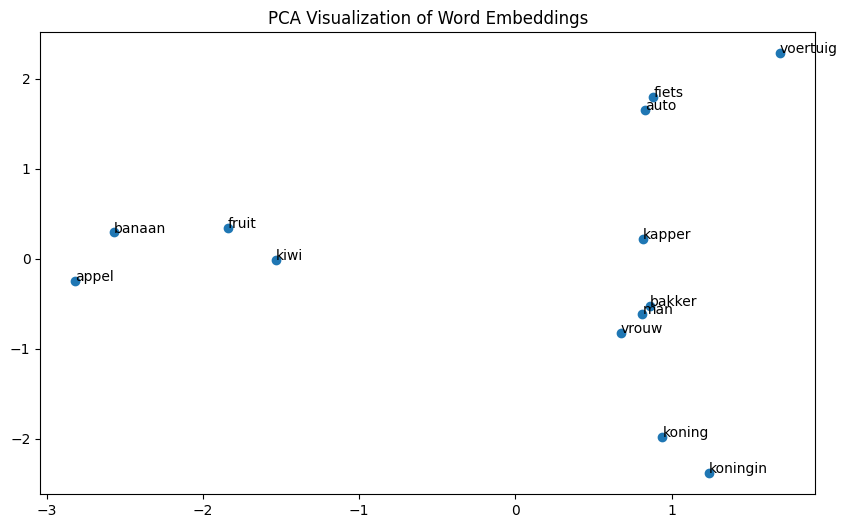

In [37]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

words = ['koning', 'koningin', 'man', 'vrouw', 'appel', 'banaan', 'fruit', 'auto', 'voertuig', 'fiets', 'kiwi', 'bakker', 'kapper']
word_vectors = np.array([model.wv[word] for word in words])

pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

plt.figure(figsize=(10, 6))
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.title("PCA Visualization of Word Embeddings")
plt.show()

In [38]:
# Get the embedding for a specific word
word = "koning"
embedding = model.wv[word]
print(f"Embedding for '{word}':\n{embedding}")

Embedding for 'koning':
[ 0.19843368 -0.19819699  0.05226972  0.0028699   0.36653805 -0.02423507
  0.27526617  0.2278679   0.02340556 -0.11467039 -0.00226623 -0.20365193
  0.16334741  0.3195048   0.03726147 -0.0044836  -0.07675403  0.28550625
  0.06234403 -0.01450028 -0.0539869  -0.31572407  0.1265183  -0.00553787
 -0.21602516 -0.04983663 -0.25920507 -0.58938885 -0.43391797  0.28615615
  0.07514975  0.02848508  0.1987885  -0.20343548 -0.10483617  0.28077054
  0.01312405 -0.14299479 -0.03465247 -0.6306779  -0.2458529   0.17400725
  0.2936017   0.6712559  -0.03861365 -0.13354172 -0.06298587 -0.67664504
 -0.01370457  0.35713887 -0.2875449  -0.11635721 -0.08509432 -0.1986717
  0.03926133 -0.04125953 -0.16944593 -0.06946542 -0.41166106  0.27019325
 -0.17359395  0.24586101  0.28969783  0.16811505 -0.38107735  0.01424757
  0.20994608  0.2957541   0.10699153  0.03021304  0.0375849  -0.1563504
  0.30527905 -0.2237855   0.11595438  0.0662626   0.22603427 -0.06052596
 -0.3114254  -0.5623082   0.0

In [41]:
# Load the SimLex-999 Dutch dataset
simlex_path = '/Users/jonasklein/word2vec/SimLex-999-Dutch-final.txt'
df = pd.read_csv(simlex_path, sep='\t')

# Preview dataset
print(df.head())

# Filter pairs for words present in the model's vocabulary
filtered_pairs = [
    (w1, w2, sim) for w1, w2, sim in zip(df['word1'], df['word2'], df['SimLex999'])
    if w1 in model.wv.key_to_index and w2 in model.wv.key_to_index
]

# Compute model similarity scores
model_similarities = [model.wv.similarity(w1, w2) for w1, w2, _ in filtered_pairs]

# Extract human ratings from dataset
human_similarities = [sim for _, _, sim in filtered_pairs]

# Compute Spearman correlation
spearman_corr, _ = spearmanr(model_similarities, human_similarities)

print(f"Spearman correlation between model and human ratings: {spearman_corr:.4f}")

      word1        word2  SimLex999 POS
0       oud        nieuw       1.94   A
1      slim  intelligent       8.19   A
2      hard     moeilijk       4.46   A
3  gelukkig      vrolijk       6.49   A
4      hard        stoer       5.69   A
Spearman correlation between model and human ratings: 0.3707
